# Baseline — Block bootstrap multivariante

Primera implementación didáctica del baseline principal. El objetivo es generar trayectorias conjuntas de retornos BTC–ETH de 30 días remuestreando **bloques temporales completos**, nunca observaciones o activos por separado.

Usamos deliberadamente una versión no condicionada: debe ser un baseline clásico, transparente y fácil de reproducir frente a los modelos generativos.

## Decisiones metodológicas

- Solo se usan datos cubiertos por `train_sample_ids`.
- Se recuperan retornos temporales únicos: las ventanas solapadas no deben ponderar repetidamente las mismas velas.
- Cada bloque conserva conjuntamente `[retorno_BTC, retorno_ETH]`.
- Ningún bloque puede atravesar huecos o velas truncadas.
- La trayectoria objetivo tiene 120 pasos de 6 horas.
- La longitud del bloque es provisional y deberá seleccionarse con validación, nunca con prueba.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SOURCE_ROOT = PROJECT_ROOT / 'src'
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from crypto_generative.evaluation import (
    CrossAssetDependenceConfig,
    DiversityMemorizationConfig,
    RiskMetricsConfig,
    TemporalDependenceConfig,
    TrajectoryEvaluator,
    TrajectoryMetricsConfig,
)
from crypto_generative.models import MultivariateBlockBootstrap

SEED = 42
INTERVAL_HOURS = 6
HORIZON_STEPS = 120  # 30 días
PROVISIONAL_BLOCK_LENGTH = 20  # 5 días; todavía no está congelado
N_SCENARIOS = 2_000

PANEL_PATH = PROJECT_ROOT / 'data/processed/binance/btc_eth_6h_panel.csv'
SPLIT_INDEX_PATH = (
    PROJECT_ROOT
    / 'data/splits/binance/btc_eth_6h_c240_t120_purged_split_index.csv'
)

assert PANEL_PATH.exists(), f'No existe {PANEL_PATH}'
assert SPLIT_INDEX_PATH.exists(), f'No existe {SPLIT_INDEX_PATH}'

## 1. Cargar el panel y el split congelado

El panel limpio está versionado en Git. El índice del split indica qué intervalos completos pertenecen al entrenamiento. No usamos validación, prueba ni purgas para ajustar el bootstrap.

In [2]:
panel = pd.read_csv(PANEL_PATH)
split_index = pd.read_csv(SPLIT_INDEX_PATH)

panel_datetime_columns = ['open_time_utc', 'expected_close_time_utc']
split_datetime_columns = [
    'condition_start_utc',
    'condition_end_utc',
    'target_start_utc',
    'target_end_utc',
]
for column in panel_datetime_columns:
    panel[column] = pd.to_datetime(panel[column], utc=True)
for column in split_datetime_columns:
    split_index[column] = pd.to_datetime(split_index[column], utc=True)

train_index = split_index.loc[split_index['split'].eq('train')].copy()
assert len(train_index) == 4_710, (
    f'Se esperaban 4.710 muestras train y se encontraron {len(train_index):,}'
)

print(f'Filas del panel: {len(panel):,}')
print(f'Muestras train: {len(train_index):,}')
print(
    'Cobertura de objetivos train:',
    train_index['target_start_utc'].min(),
    '→',
    train_index['target_end_utc'].max(),
)

Filas del panel: 13,081
Muestras train: 4,710
Cobertura de objetivos train: 2017-11-06 00:00:00+00:00 → 2023-07-30 12:00:00+00:00


## 2. Reconstruir retornos únicos de entrenamiento

Una muestra del dataset comparte la mayoría de sus retornos con muestras vecinas. Concatenar las 4.710 trayectorias de entrenamiento multiplicaría artificialmente el peso de las mismas fechas.

Aquí marcamos la **unión temporal** de todos los intervalos de entrenamiento y calculamos cada retorno una sola vez. La validez exige dos velas consecutivas completas y separadas exactamente seis horas.

In [3]:
panel = panel.sort_values('open_time_utc').reset_index(drop=True)
expected_delta = pd.Timedelta(hours=INTERVAL_HOURS)
regular_step = panel['open_time_utc'].diff().eq(expected_delta)
current_complete = panel['is_complete'].eq(1)
previous_complete = current_complete.shift(1, fill_value=False)
panel['returns_valid'] = regular_step & current_complete & previous_complete

for asset in ('btc', 'eth'):
    panel[f'{asset}_log_return'] = np.log(panel[f'{asset}_close']).diff()

def interval_union_mask(
    intervals: pd.DataFrame,
    start_column: str,
    end_column: str,
    timestamp_index: pd.DatetimeIndex,
) -> np.ndarray:
    """Máscara de la unión de intervalos cerrados sobre el panel UTC."""
    coverage_delta = np.zeros(len(timestamp_index) + 1, dtype=np.int64)
    for row in intervals.itertuples(index=False):
        start_time = getattr(row, start_column)
        end_time = getattr(row, end_column)
        start = timestamp_index.searchsorted(start_time, side='left')
        stop = timestamp_index.searchsorted(end_time, side='right')
        if start == stop or start == len(timestamp_index):
            raise RuntimeError(f'Intervalo fuera del panel: {start_time} → {end_time}')
        coverage_delta[start] += 1
        coverage_delta[stop] -= 1
    return np.cumsum(coverage_delta[:-1]) > 0


# La unión evita contar muchas veces el mismo retorno por el solapamiento.
timestamp_index = pd.DatetimeIndex(panel['open_time_utc'])
covered_by_train = interval_union_mask(
    train_index,
    'condition_start_utc',
    'target_end_utc',
    timestamp_index,
)
assert panel.loc[covered_by_train, 'returns_valid'].all(), (
    'Una ventana train contiene retornos no válidos; revisar el pipeline.'
)

train_returns = panel.loc[
    covered_by_train,
    ['open_time_utc', 'btc_log_return', 'eth_log_return'],
].copy()

# Un nuevo segmento comienza cuando entre retornos cubiertos hay más de 6 horas.
train_returns['segment_id'] = (
    train_returns['open_time_utc'].diff().ne(expected_delta).cumsum()
)
segment_lengths = train_returns.groupby('segment_id').size()

print(f'Retornos temporales únicos de train: {len(train_returns):,}')
print(f'Segmentos contiguos: {len(segment_lengths)}')
print('Longitudes por segmento:', segment_lengths.to_list())
assert len(train_returns) == 8_300

Retornos temporales únicos de train: 8,300
Segmentos contiguos: 10
Longitudes por segmento: [616, 546, 530, 470, 365, 751, 1223, 496, 438, 2865]


## 3. Dependencia temporal y longitud del bloque

Los retornos suelen presentar poca autocorrelación lineal, pero sus valores absolutos mantienen dependencia por el agrupamiento de volatilidad. Un bloque de longitud 1 destruiría esta información.

La gráfica siguiente es diagnóstica. El valor provisional de 20 pasos (5 días) no se elegirá definitivamente hasta comparar varias longitudes sobre validación.

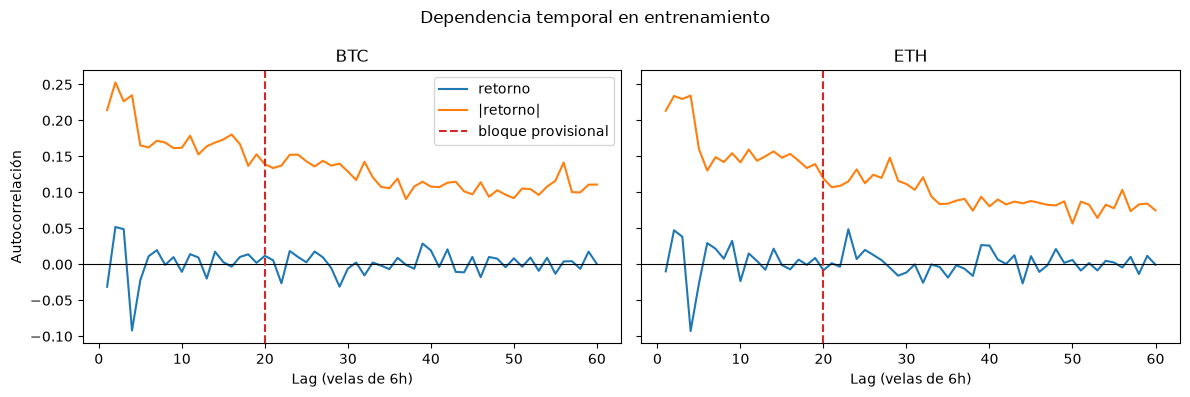

In [4]:
def segmented_autocorrelation(
    values: np.ndarray,
    segment_ids: np.ndarray,
    max_lag: int,
) -> np.ndarray:
    """ACF que excluye todos los pares situados a ambos lados de un hueco."""
    centered = values - values.mean()
    denominator = np.dot(centered, centered)
    correlations = []
    for lag in range(1, max_lag + 1):
        same_segment = segment_ids[:-lag] == segment_ids[lag:]
        numerator = np.dot(
            centered[:-lag][same_segment],
            centered[lag:][same_segment],
        )
        correlations.append(numerator / denominator)
    return np.asarray(correlations)

max_lag = 60
lags = np.arange(1, max_lag + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
segment_ids = train_returns['segment_id'].to_numpy()
for axis, asset in zip(axes, ('btc', 'eth')):
    values = train_returns[f'{asset}_log_return'].to_numpy()
    axis.plot(
        lags,
        segmented_autocorrelation(values, segment_ids, max_lag),
        label='retorno',
    )
    axis.plot(
        lags,
        segmented_autocorrelation(np.abs(values), segment_ids, max_lag),
        label='|retorno|',
    )
    axis.axhline(0, color='black', linewidth=0.8)
    axis.axvline(PROVISIONAL_BLOCK_LENGTH, color='tab:red', linestyle='--', label='bloque provisional')
    axis.set(title=asset.upper(), xlabel='Lag (velas de 6h)')
axes[0].set_ylabel('Autocorrelación')
axes[0].legend()
fig.suptitle('Dependencia temporal en entrenamiento')
fig.tight_layout()

## 4. Implementación del sampler multivariante

Se construyen todos los bloques móviles admisibles dentro de cada segmento contiguo. Al muestrear se elige uniformemente entre inicios de bloque, se concatenan bloques y se recorta al horizonte solicitado.

Esta versión es un *moving block bootstrap*. La unión entre dos bloques remuestreados puede crear una discontinuidad; es una limitación conocida que aceptamos y documentamos para mantener un baseline clásico, transparente y fácil de reproducir.

In [5]:
# La implementación reutilizable vive en crypto_generative.models.
# Este notebook conserva únicamente el uso didáctico del baseline.
print('Sampler común:', MultivariateBlockBootstrap.__name__)

Sampler común: MultivariateBlockBootstrap


In [6]:
return_columns = ['btc_log_return', 'eth_log_return']
bootstrap = MultivariateBlockBootstrap(
    block_length=PROVISIONAL_BLOCK_LENGTH,
    random_state=SEED,
).fit(
    train_returns[return_columns].to_numpy(),
    train_returns['segment_id'].to_numpy(),
)
synthetic = bootstrap.sample(
    n_scenarios=N_SCENARIOS,
    horizon_steps=HORIZON_STEPS,
)

print(f'Bloques candidatos: {len(bootstrap.blocks):,}')
print('Forma sintética:', synthetic.shape)
assert synthetic.shape == (N_SCENARIOS, HORIZON_STEPS, 2)

Bloques candidatos: 8,110
Forma sintética: (2000, 120, 2)


## 5. Sanity check mínimo

Todavía no es el evaluador definitivo. Solo comprobamos que media, volatilidad y correlación contemporánea sean razonables y que las trayectorias tengan diversidad. Las métricas finales se calcularán fuera de muestra y serán comunes a todos los modelos.

In [7]:
historical = train_returns[return_columns].to_numpy()
synthetic_flat = synthetic.reshape(-1, 2)

sanity = pd.DataFrame(
    {
        'histórico': [
            historical[:, 0].mean(),
            historical[:, 1].mean(),
            historical[:, 0].std(ddof=1),
            historical[:, 1].std(ddof=1),
            np.corrcoef(historical.T)[0, 1],
        ],
        'sintético': [
            synthetic_flat[:, 0].mean(),
            synthetic_flat[:, 1].mean(),
            synthetic_flat[:, 0].std(ddof=1),
            synthetic_flat[:, 1].std(ddof=1),
            np.corrcoef(synthetic_flat.T)[0, 1],
        ],
    },
    index=['media_BTC', 'media_ETH', 'vol_BTC', 'vol_ETH', 'corr_BTC_ETH'],
)
sanity

,histórico,sintético
media_BTC,0.000114,0.000176
media_ETH,0.000115,0.000254
vol_BTC,0.019969,0.019831
vol_ETH,0.024540,0.024297
corr_BTC_ETH,0.809180,0.805385


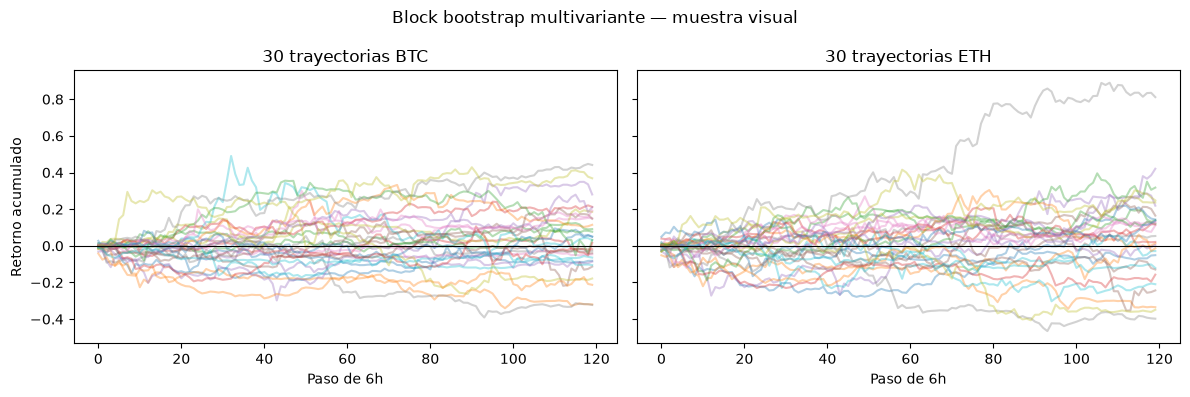

In [8]:
cumulative_simple_returns = np.exp(np.cumsum(synthetic, axis=1)) - 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for asset_index, (axis, asset) in enumerate(zip(axes, ('BTC', 'ETH'))):
    axis.plot(cumulative_simple_returns[:30, :, asset_index].T, alpha=0.35)
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set(title=f'30 trayectorias {asset}', xlabel='Paso de 6h')
axes[0].set_ylabel('Retorno acumulado')
fig.suptitle('Block bootstrap multivariante — muestra visual')
fig.tight_layout()

## 6. Selección de la longitud de bloque con validación

Comparamos bloques entre 1 vela (bootstrap IID) y 120 velas (todo el horizonte). Cada sampler se **ajusta exclusivamente con los retornos únicos de train** y se enfrenta a los objetivos reales de **validación**. Prueba queda completamente al margen.

No existe una única distancia perfecta, así que usamos cinco criterios complementarios: marginales, retorno acumulado a 30 días, volatilidad realizada, correlación BTC–ETH por trayectoria y autocorrelación de retornos absolutos. Como sus escalas son distintas, la decisión usa el rango medio de las métricas, todas con el mismo peso. Esta regla queda fijada antes de observar prueba.

In [9]:
NORMALIZED_PATH = (
    PROJECT_ROOT
    / 'data/normalized/binance/btc_eth_6h_c240_t120_train_normalized.npz'
)
assert NORMALIZED_PATH.exists(), f'No existe {NORMALIZED_PATH}'

validation_index = split_index.loc[split_index['split'].eq('validation')].copy()
training_ids = train_index['sample_id'].to_numpy(dtype=np.int64)
validation_ids = validation_index['sample_id'].to_numpy(dtype=np.int64)
assert len(training_ids) == 4_710
assert len(validation_ids) == 1_832

def load_denormalized_targets(
    path: Path,
    sample_ids: np.ndarray,
) -> np.ndarray:
    """Carga por ID retornos objetivo en su escala logarítmica original."""
    with np.load(path, allow_pickle=False) as normalized:
        stored_sample_ids = normalized['sample_ids'].astype(np.int64)
        id_to_position = pd.Series(
            np.arange(len(stored_sample_ids)),
            index=stored_sample_ids,
        )
        positions = id_to_position.loc[sample_ids].to_numpy()
        return (
            normalized['target_returns'][positions]
            * normalized['return_scale']
            + normalized['return_mean']
        )


# Se extraen únicamente train y validación; prueba permanece intacta.
training_targets = load_denormalized_targets(NORMALIZED_PATH, training_ids)
validation_targets = load_denormalized_targets(NORMALIZED_PATH, validation_ids)

assert training_targets.shape == (4_710, HORIZON_STEPS, 2)
assert validation_targets.shape == (1_832, HORIZON_STEPS, 2)
assert np.isfinite(training_targets).all()
assert np.isfinite(validation_targets).all()

# Para las marginales usamos la unión de objetivos: cada fecha valida pesa una vez.
covered_by_validation_target = interval_union_mask(
    validation_index,
    'target_start_utc',
    'target_end_utc',
    timestamp_index,
)
assert panel.loc[covered_by_validation_target, 'returns_valid'].all()
validation_unique_returns = panel.loc[
    covered_by_validation_target,
    return_columns,
].to_numpy()

print(f'Trayectorias de validación: {len(validation_targets):,}')
print(f'Retornos objetivo únicos de validación: {len(validation_unique_returns):,}')
print('Prueba consultada: no')

Trayectorias de validación: 1,832
Retornos objetivo únicos de validación: 1,951
Prueba consultada: no


### Métricas de selección

La distancia de Wasserstein se aproxima comparando cuantiles empíricos. La normalizamos por la desviación típica de la referencia cuando la unidad de medida lo requiere. La ACF se calcula dentro de cada trayectoria: nunca se crean pares artificiales entre el final de una trayectoria y el comienzo de otra.

In [10]:
def normalized_quantile_distance(
    reference: np.ndarray,
    candidate: np.ndarray,
    *,
    normalize: bool = True,
    n_quantiles: int = 1_001,
) -> float:
    """Wasserstein-1 empírica aproximada, opcionalmente sin unidades."""
    reference = np.asarray(reference, dtype=np.float64).ravel()
    candidate = np.asarray(candidate, dtype=np.float64).ravel()
    if not (np.isfinite(reference).all() and np.isfinite(candidate).all()):
        raise ValueError('La distancia recibió valores no finitos')
    probabilities = np.linspace(0.0, 1.0, n_quantiles)
    distance = np.mean(
        np.abs(
            np.quantile(reference, probabilities)
            - np.quantile(candidate, probabilities)
        )
    )
    if not normalize:
        return float(distance)
    scale = reference.std(ddof=1)
    if scale <= 0:
        raise ValueError('La referencia tiene escala nula')
    return float(distance / scale)


def path_statistics(paths: np.ndarray) -> dict[str, np.ndarray]:
    """Estadísticos por trayectoria, sin mezclar observaciones entre paths."""
    paths = np.asarray(paths, dtype=np.float64)
    if paths.ndim != 3 or paths.shape[-1] != 2:
        raise ValueError('paths debe tener forma [trayectorias, tiempo, 2]')
    centered = paths - paths.mean(axis=1, keepdims=True)
    standard_deviation = paths.std(axis=1, ddof=1)
    covariance = np.sum(centered[:, :, 0] * centered[:, :, 1], axis=1)
    covariance /= paths.shape[1] - 1
    correlation = covariance / (
        standard_deviation[:, 0] * standard_deviation[:, 1]
    )
    return {
        'cumulative_log_return': paths.sum(axis=1),
        'annualized_volatility': standard_deviation * np.sqrt(4 * 365),
        'correlation': correlation,
    }


def pooled_absolute_return_acf(paths: np.ndarray, max_lag: int = 20) -> np.ndarray:
    """ACF agrupada por activo que respeta los límites de cada trayectoria."""
    absolute_returns = np.abs(np.asarray(paths, dtype=np.float64))
    centered = absolute_returns - absolute_returns.mean(
        axis=(0, 1),
        keepdims=True,
    )
    correlations = []
    for lag in range(1, max_lag + 1):
        left = centered[:, :-lag, :]
        right = centered[:, lag:, :]
        numerator = np.sum(left * right, axis=(0, 1))
        denominator = np.sqrt(
            np.sum(left**2, axis=(0, 1))
            * np.sum(right**2, axis=(0, 1))
        )
        correlations.append(numerator / denominator)
    return np.asarray(correlations)


validation_statistics = path_statistics(validation_targets)
validation_absolute_acf = pooled_absolute_return_acf(validation_targets)

In [11]:
BLOCK_LENGTHS = [1, 4, 12, 20, 28, 40, 60, 120]
SELECTION_SCENARIOS = 5_000
METRIC_COLUMNS = [
    'marginal_return_w1',
    'cumulative_return_w1',
    'realized_volatility_w1',
    'path_correlation_w1',
    'absolute_return_acf_rmse',
]

def evaluate_paths_against_validation(candidate_paths: np.ndarray) -> dict[str, float]:
    """Aplica exactamente los cinco criterios fijados para validación."""
    candidate_statistics = path_statistics(candidate_paths)
    candidate_absolute_acf = pooled_absolute_return_acf(candidate_paths)
    return {
        'marginal_return_w1': np.mean([
            normalized_quantile_distance(
                validation_unique_returns[:, asset],
                candidate_paths[:, :, asset],
            )
            for asset in range(2)
        ]),
        'cumulative_return_w1': np.mean([
            normalized_quantile_distance(
                validation_statistics['cumulative_log_return'][:, asset],
                candidate_statistics['cumulative_log_return'][:, asset],
            )
            for asset in range(2)
        ]),
        'realized_volatility_w1': np.mean([
            normalized_quantile_distance(
                validation_statistics['annualized_volatility'][:, asset],
                candidate_statistics['annualized_volatility'][:, asset],
            )
            for asset in range(2)
        ]),
        'path_correlation_w1': normalized_quantile_distance(
            validation_statistics['correlation'],
            candidate_statistics['correlation'],
            normalize=False,
        ),
        'absolute_return_acf_rmse': np.sqrt(
            np.mean((candidate_absolute_acf - validation_absolute_acf) ** 2)
        ),
    }


train_values = train_returns[return_columns].to_numpy()
train_segment_ids = train_returns['segment_id'].to_numpy()
metric_rows = []

for block_length in BLOCK_LENGTHS:
    candidate_sampler = MultivariateBlockBootstrap(
        block_length=block_length,
        random_state=SEED + block_length,
    ).fit(train_values, train_segment_ids)
    candidate_paths = candidate_sampler.sample(
        n_scenarios=SELECTION_SCENARIOS,
        horizon_steps=HORIZON_STEPS,
    )
    candidate_metrics = evaluate_paths_against_validation(candidate_paths)

    metric_rows.append({
        'block_length_steps': block_length,
        'block_length_days': block_length * INTERVAL_HOURS / 24,
        'candidate_blocks': len(candidate_sampler.blocks),
        **candidate_metrics,
    })

selection_results = pd.DataFrame(metric_rows)
rank_columns = []
for metric in METRIC_COLUMNS:
    rank_column = f'{metric}_rank'
    selection_results[rank_column] = selection_results[metric].rank(
        method='average',
        ascending=True,
    )
    rank_columns.append(rank_column)
selection_results['mean_rank'] = selection_results[rank_columns].mean(axis=1)
selection_results = selection_results.sort_values(
    ['mean_rank', 'block_length_steps'],
).reset_index(drop=True)
SELECTED_BLOCK_LENGTH = int(selection_results.loc[0, 'block_length_steps'])

display_columns = [
    'block_length_steps',
    'block_length_days',
    'candidate_blocks',
    *METRIC_COLUMNS,
    'mean_rank',
]
selection_results[display_columns].style.format(precision=4)

,block_length_steps,block_length_days,candidate_blocks,marginal_return_w1,cumulative_return_w1,realized_volatility_w1,path_correlation_w1,absolute_return_acf_rmse,mean_rank
0,12,3.0000,8190,0.3341,0.4775,2.4064,0.0250,0.0445,3.4000
1,40,10.0000,7910,0.3221,0.4877,2.2024,0.0435,0.0976,4.0000
2,1,0.2500,8300,0.3372,0.4860,2.5372,0.0238,0.0630,4.6000
3,28,7.0000,8030,0.3331,0.5033,2.3284,0.0369,0.0743,4.6000
4,120,30.0000,7110,0.3114,0.5128,1.9264,0.0620,0.1272,4.6000
5,20,5.0000,8110,0.3318,0.5153,2.3543,0.0343,0.0634,4.8000
6,4,1.0000,8270,0.3363,0.5310,2.4861,0.0204,0.0465,5.0000
7,60,15.0000,7710,0.3258,0.5142,2.1747,0.0522,0.1148,5.0000


Longitud seleccionada: 12 pasos de 6h (3 días).
Conjunto de prueba consultado durante la selección: no.


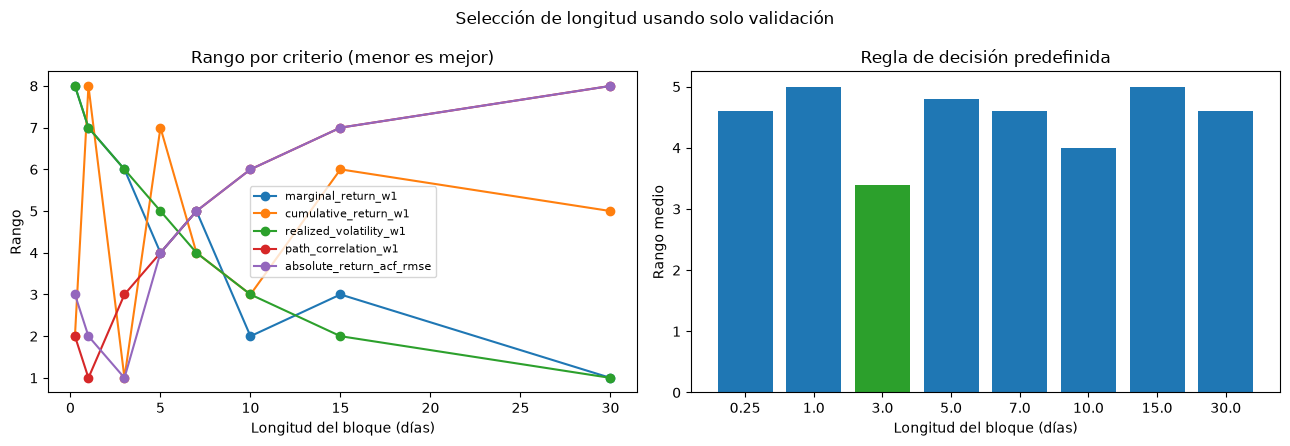

In [12]:
results_by_length = selection_results.sort_values('block_length_steps')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for metric, rank_column in zip(METRIC_COLUMNS, rank_columns):
    axes[0].plot(
        results_by_length['block_length_days'],
        results_by_length[rank_column],
        marker='o',
        label=metric,
    )
axes[0].set(
    title='Rango por criterio (menor es mejor)',
    xlabel='Longitud del bloque (días)',
    ylabel='Rango',
)
axes[0].legend(fontsize=8)

bar_colors = [
    'tab:green' if length == SELECTED_BLOCK_LENGTH else 'tab:blue'
    for length in results_by_length['block_length_steps']
]
axes[1].bar(
    results_by_length['block_length_days'].astype(str),
    results_by_length['mean_rank'],
    color=bar_colors,
)
axes[1].set(
    title='Regla de decisión predefinida',
    xlabel='Longitud del bloque (días)',
    ylabel='Rango medio',
)
fig.suptitle('Selección de longitud usando solo validación')
fig.tight_layout()

selected_days = SELECTED_BLOCK_LENGTH * INTERVAL_HOURS / 24
print(
    f'Longitud seleccionada: {SELECTED_BLOCK_LENGTH} pasos de 6h '
    f'({selected_days:g} días).'
)
print('Conjunto de prueba consultado durante la selección: no.')

### Resultado e interpretación

La regla predefinida selecciona **12 pasos de 6 horas (3 días)**, con rango medio 3,4; el segundo resultado es 40 pasos (10 días), con rango medio 4,0. La opción elegida logra el mejor equilibrio entre los cinco criterios, no necesariamente el mínimo en cada uno por separado.

Hay una advertencia importante: la distancia de volatilidad realizada es elevada para todas las longitudes. Esto apunta a un cambio de régimen entre train y validación que un bootstrap histórico no condicionado no puede corregir solo modificando el tamaño de bloque. La longitud de 3 días queda congelada para este baseline, pero la limitación deberá constar en la evaluación final. **Prueba no se ha usado ni para calcular las métricas ni para desempatar.**

## 7. Aplicar el evaluador común

Congelamos el *moving bootstrap* con los 12 pasos elegidos y generamos un lote nuevo. Solo después de congelar la longitud consultamos **test** y lo usamos como referencia del mismo `TrajectoryEvaluator` importable que utilizan los modelos generativos. Tanto la referencia como el candidato están en retornos logarítmicos originales.

In [13]:
test_index = split_index.loc[split_index['split'].eq('test')].copy()
test_ids = test_index['sample_id'].to_numpy(dtype=np.int64)
assert len(test_ids) == 1_826
test_targets = load_denormalized_targets(NORMALIZED_PATH, test_ids)
assert test_targets.shape == (1_826, HORIZON_STEPS, 2)
assert np.isfinite(test_targets).all()

FINAL_EVALUATION_SCENARIOS = 5_000
selected_bootstrap = MultivariateBlockBootstrap(
    block_length=SELECTED_BLOCK_LENGTH,
    random_state=SEED + 5_000,
).fit(train_values, train_segment_ids)
selected_synthetic = selected_bootstrap.sample(
    n_scenarios=FINAL_EVALUATION_SCENARIOS,
    horizon_steps=HORIZON_STEPS,
)

common_evaluator = TrajectoryEvaluator(assets=['BTC', 'ETH'])
temporal_config = TemporalDependenceConfig(
    max_lag=20,
    volatility_window=20,
    high_volatility_quantile=0.90,
    extreme_quantile=0.99,
    extreme_clustering_window=4,
)
marginal_report = common_evaluator.evaluate_marginals(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
)
temporal_report = common_evaluator.evaluate_temporal_dependence(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    config=temporal_config,
)
cross_asset_config = CrossAssetDependenceConfig(
    rolling_window=20,
    stress_quantile=0.90,
    joint_drop_quantile=0.05,
    lower_tail_quantile=0.05,
)
cross_asset_report = common_evaluator.evaluate_cross_asset_dependence(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    config=cross_asset_config,
)
trajectory_report = common_evaluator.evaluate_trajectories(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)
risk_report = common_evaluator.evaluate_risk(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    config=RiskMetricsConfig(
        confidence_levels=(0.95, 0.99),
        portfolio_weights=(0.60, 0.40),
        portfolio_name='portfolio_60_40',
        es_stability_repetitions=100,
        es_stability_sample_size=1_000,
        random_state=SEED,
    ),
)
diversity_report = common_evaluator.evaluate_diversity_and_memorization(
    reference_paths=test_targets,
    candidate_paths=selected_synthetic,
    training_paths=training_targets,
    config=DiversityMemorizationConfig(
        max_paths_per_set=2_000,
        projection_dimensions=24,
        neighbor_candidates=8,
        near_memorization_quantile=0.01,
        coverage_radius_quantile=0.95,
        discriminator_repetitions=5,
        random_state=SEED,
    ),
)

marginal_table = pd.DataFrame(marginal_report.to_records())
temporal_table = pd.DataFrame(temporal_report.to_records())
cross_asset_table = pd.DataFrame(cross_asset_report.to_records())
trajectory_table = pd.DataFrame(trajectory_report.to_records())
risk_table = pd.DataFrame(risk_report.to_records())
diversity_table = pd.DataFrame(diversity_report.to_records())
display(marginal_table)
display(temporal_table)
display(cross_asset_table.T.rename(columns={0: 'valor'}))
display(trajectory_table[[
    'asset',
    'metric',
    'reference_mean',
    'candidate_mean',
    'normalized_wasserstein_1',
]])
display(risk_table[[
    'target',
    'confidence_level',
    'reference_unconditional_var',
    'candidate_unconditional_var',
    'reference_unconditional_es',
    'candidate_unconditional_es',
    'exception_rate',
    'expected_exception_rate',
    'coverage_absolute_error',
    'candidate_es_stability_relative_standard_deviation',
]])
display(diversity_table.T.rename(columns={0: 'valor'}))
print(f'Trayectorias de test evaluadas: {len(test_targets):,}')
print('Conjunto de prueba consultado únicamente tras congelar el modelo: sí')

,asset,wasserstein_1,normalized_wasserstein_1,extreme_threshold,reference_mean,reference_standard_deviation,reference_skewness,reference_excess_kurtosis,reference_extreme_frequency,reference_mean_absolute_extreme,...,candidate_standard_deviation,candidate_skewness,candidate_excess_kurtosis,candidate_extreme_frequency,candidate_mean_absolute_extreme,candidate_q01,candidate_q05,candidate_q50,candidate_q95,candidate_q99
0,BTC,0.005290,0.484685,0.041664,-0.000164,0.010913,-0.248185,4.823216,0.010054,0.049300,...,0.019916,-0.450354,11.717088,0.051417,0.061903,-0.061494,-0.030580,0.000373,0.029794,0.058913
1,ETH,0.004661,0.272997,0.062694,0.000046,0.017073,0.109115,4.760664,0.010268,0.074174,...,0.024385,-0.520151,9.021050,0.029567,0.085149,-0.072132,-0.038332,0.000414,0.037247,0.069499


,asset,high_volatility_threshold,extreme_threshold,return_acf_rmse,absolute_return_acf_rmse,squared_return_acf_rmse,volatility_persistence_absolute_error,high_volatility_frequency_absolute_error,mean_high_volatility_run_length_absolute_error,p95_high_volatility_run_length_absolute_error,...,reference_volatility_persistence,reference_high_volatility_frequency,reference_mean_high_volatility_run_length,reference_p95_high_volatility_run_length,reference_extreme_clustering_ratio,candidate_volatility_persistence,candidate_high_volatility_frequency,candidate_mean_high_volatility_run_length,candidate_p95_high_volatility_run_length,candidate_extreme_clustering_ratio
0,BTC,0.015025,0.041664,0.026156,0.065497,0.073021,0.315852,0.464556,1.095519,7.0,...,1.477953,0.100187,18.114706,59.0,7.748764,1.162101,0.564743,19.210225,52.0,2.392206
1,ETH,0.024041,0.062694,0.030241,0.071414,0.070202,0.093766,0.248558,4.542926,9.0,...,1.182976,0.100295,10.208057,28.0,3.169721,1.089210,0.348853,14.750984,37.0,3.192206


,valor
asset_pair,BTC-ETH
stress_threshold,1.610967
joint_drop_threshold_BTC,-0.016784
joint_drop_threshold_ETH,-0.02701
contemporaneous_correlation_absolute_error,0.03998
rolling_correlation_wasserstein_1,0.027768
calm_correlation_absolute_error,0.026376
stress_correlation_absolute_error,0.112661
stress_frequency_absolute_error,0.362343
joint_drop_probability_absolute_error,0.03431


,asset,metric,reference_mean,candidate_mean,normalized_wasserstein_1
0,BTC,final_cumulative_return,-0.011770,0.050336,0.712806
1,BTC,realized_volatility,0.401675,0.739748,3.041638
2,BTC,maximum_drawdown,0.125104,0.198721,0.969752
3,BTC,maximum_drawdown_duration_steps,76.387185,71.478800,0.159715
4,BTC,intrahorizon_maximum_return,0.077872,0.190704,1.786248
5,BTC,intrahorizon_minimum_return,-0.088375,-0.129027,0.481431
6,BTC,time_to_minimum_value_steps,56.887733,54.796400,0.052609
7,ETH,final_cumulative_return,0.030695,0.063799,0.227362
8,ETH,realized_volatility,0.637460,0.911106,2.057258
9,ETH,maximum_drawdown,0.180943,0.243323,0.686682


,target,confidence_level,reference_unconditional_var,candidate_unconditional_var,reference_unconditional_es,candidate_unconditional_es,exception_rate,expected_exception_rate,coverage_absolute_error,candidate_es_stability_relative_standard_deviation
0,BTC,0.95,0.237172,0.281425,0.263418,0.354627,0.009310,0.05,0.040690,0.037924
1,BTC,0.99,0.279421,0.404002,0.290909,0.464617,0.000000,0.01,0.010000,0.051631
2,ETH,0.95,0.321478,0.336512,0.363009,0.422890,0.040526,0.05,0.009474,0.035917
3,ETH,0.99,0.387959,0.474912,0.404445,0.539297,0.000000,0.01,0.010000,0.046095
4,portfolio_60_40,0.95,0.271125,0.287596,0.302357,0.369979,0.031763,0.05,0.018237,0.035362
5,portfolio_60_40,0.99,0.324836,0.421716,0.335168,0.484445,0.000000,0.01,0.010000,0.046453


,valor
total_reference_paths,1826.000000
total_candidate_paths,5000.000000
total_training_paths,4710.000000
evaluated_reference_paths,1826.000000
evaluated_candidate_paths,2000.000000
evaluated_training_paths,2000.000000
candidate_unique_fraction,1.000000
candidate_redundant_fraction,0.000000
near_duplicate_threshold,0.539349
candidate_near_duplicate_fraction,0.000000


Trayectorias de test evaluadas: 1,826
Conjunto de prueba consultado únicamente tras congelar el modelo: sí


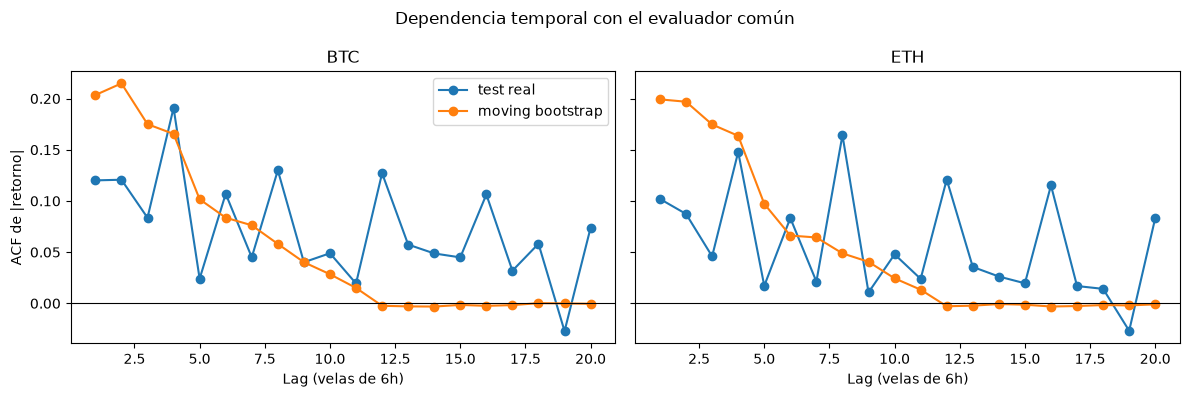

In [14]:
temporal_lags = np.arange(1, temporal_config.max_lag + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, asset in zip(axes, ('BTC', 'ETH')):
    asset_report = temporal_report.by_asset[asset]
    axis.plot(
        temporal_lags,
        asset_report.reference.absolute_return_acf,
        marker='o',
        label='test real',
    )
    axis.plot(
        temporal_lags,
        asset_report.candidate.absolute_return_acf,
        marker='o',
        label='moving bootstrap',
    )
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set(title=asset, xlabel='Lag (velas de 6h)')
axes[0].set_ylabel('ACF de |retorno|')
axes[0].legend()
fig.suptitle('Dependencia temporal con el evaluador común')
fig.tight_layout()

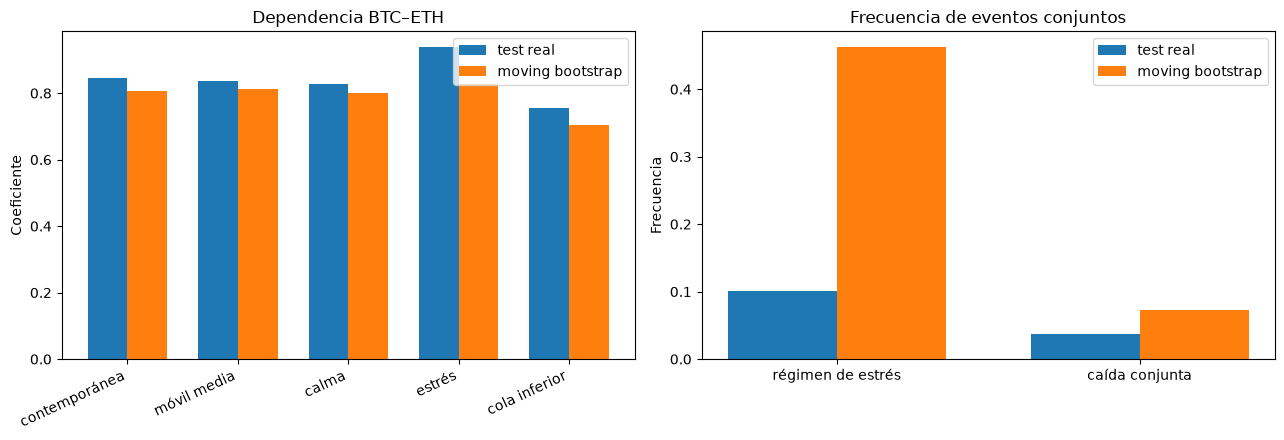

In [15]:
dependence_labels = [
    'contemporánea',
    'móvil media',
    'calma',
    'estrés',
    'cola inferior',
]
reference_dependence = [
    cross_asset_report.reference.contemporaneous_correlation,
    cross_asset_report.reference.rolling_correlation.mean,
    cross_asset_report.reference.calm_correlation,
    cross_asset_report.reference.stress_correlation,
    cross_asset_report.reference.lower_tail_dependence,
]
candidate_dependence = [
    cross_asset_report.candidate.contemporaneous_correlation,
    cross_asset_report.candidate.rolling_correlation.mean,
    cross_asset_report.candidate.calm_correlation,
    cross_asset_report.candidate.stress_correlation,
    cross_asset_report.candidate.lower_tail_dependence,
]

x_positions = np.arange(len(dependence_labels))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(x_positions - 0.18, reference_dependence, 0.36, label='test real')
axes[0].bar(x_positions + 0.18, candidate_dependence, 0.36, label='moving bootstrap')
axes[0].set_xticks(x_positions, dependence_labels, rotation=25, ha='right')
axes[0].set(title='Dependencia BTC–ETH', ylabel='Coeficiente')
axes[0].legend()

event_labels = ['régimen de estrés', 'caída conjunta']
reference_events = [
    cross_asset_report.reference.stress_frequency,
    cross_asset_report.reference.joint_drop_probability,
]
candidate_events = [
    cross_asset_report.candidate.stress_frequency,
    cross_asset_report.candidate.joint_drop_probability,
]
event_positions = np.arange(len(event_labels))
axes[1].bar(event_positions - 0.18, reference_events, 0.36, label='test real')
axes[1].bar(event_positions + 0.18, candidate_events, 0.36, label='moving bootstrap')
axes[1].set_xticks(event_positions, event_labels)
axes[1].set(title='Frecuencia de eventos conjuntos', ylabel='Frecuencia')
axes[1].legend()
fig.tight_layout()

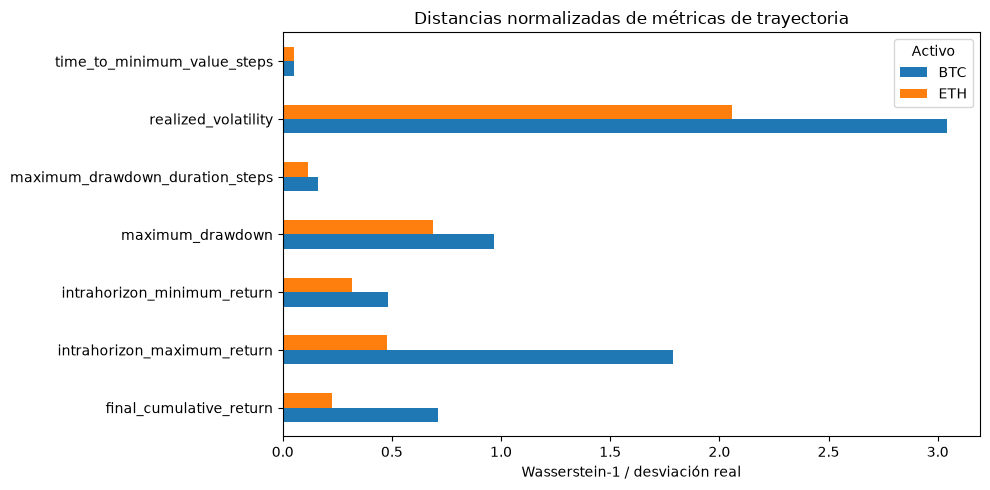

In [16]:
trajectory_distance_table = trajectory_table.pivot(
    index='metric',
    columns='asset',
    values='normalized_wasserstein_1',
)
axis = trajectory_distance_table.plot.barh(
    figsize=(10, 5),
    title='Distancias normalizadas de métricas de trayectoria',
)
axis.set(xlabel='Wasserstein-1 / desviación real', ylabel='')
axis.legend(title='Activo')
axis.figure.tight_layout()

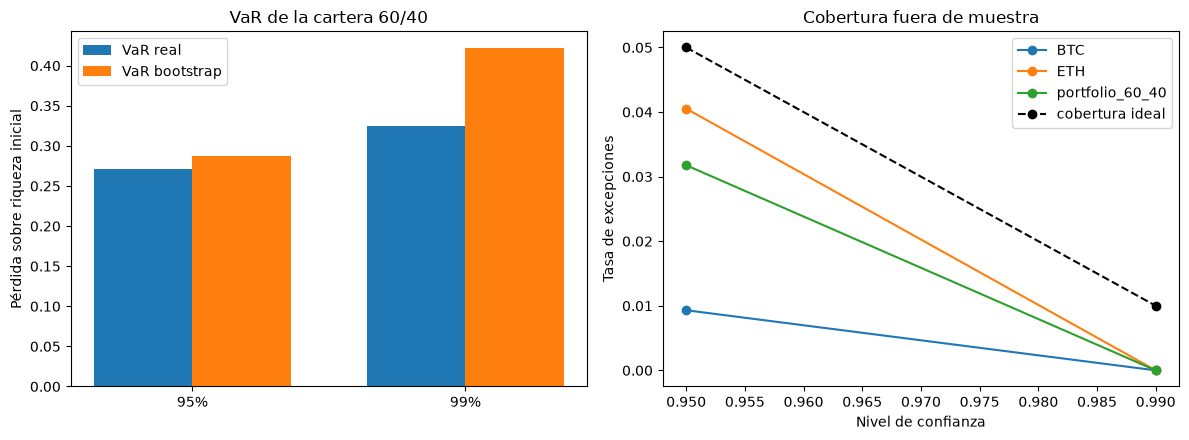

In [17]:
portfolio_risk = risk_table.loc[risk_table['target'].eq('portfolio_60_40')]
risk_positions = np.arange(len(portfolio_risk))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    risk_positions - 0.18,
    portfolio_risk['reference_unconditional_var'],
    0.36,
    label='VaR real',
)
axes[0].bar(
    risk_positions + 0.18,
    portfolio_risk['candidate_unconditional_var'],
    0.36,
    label='VaR bootstrap',
)
axes[0].set_xticks(
    risk_positions,
    [f'{level:.0%}' for level in portfolio_risk['confidence_level']],
)
axes[0].set(title='VaR de la cartera 60/40', ylabel='Pérdida sobre riqueza inicial')
axes[0].legend()

for target, target_table in risk_table.groupby('target', sort=False):
    axes[1].plot(
        target_table['confidence_level'],
        target_table['exception_rate'],
        marker='o',
        label=target,
    )
axes[1].plot(
    portfolio_risk['confidence_level'],
    portfolio_risk['expected_exception_rate'],
    color='black',
    linestyle='--',
    marker='o',
    label='cobertura ideal',
)
axes[1].set(
    title='Cobertura fuera de muestra',
    xlabel='Nivel de confianza',
    ylabel='Tasa de excepciones',
)
axes[1].legend()
fig.tight_layout()

### Interpretación de riesgo

El bootstrap sigue siendo **conservador**, aunque la diferencia es menor que al compararlo con validación. Para la cartera 60/40 estima VaR del 28,76 % y 42,17 % al 95 % y 99 %, frente a 27,11 % y 32,48 % en test. El ES sintético alcanza 37,00 % y 48,44 %, frente a 30,24 % y 33,52 % reales.

La tasa de excepciones es del 3,18 % al 95 % y del 0 % al 99 %, ambas por debajo del 5 % y 1 % esperados; el conservadurismo se concentra especialmente en la cola más extrema. Estos resultados son descriptivos porque las ventanas de test se solapan y no deben interpretarse como un backtest clásico con observaciones independientes.

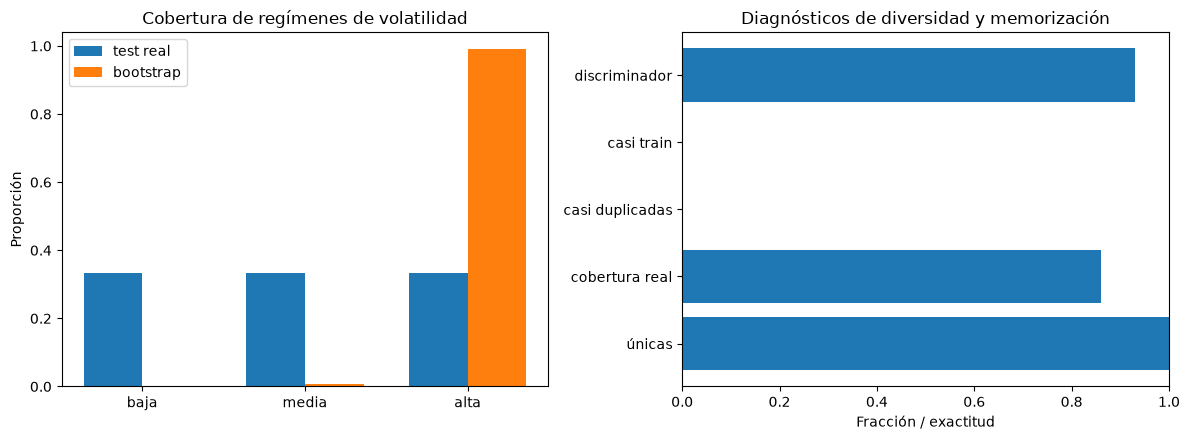

In [18]:
regime_names = ['low', 'medium', 'high']
regime_positions = np.arange(len(regime_names))
reference_regimes = [
    diversity_report.reference_regime_proportions[name]
    for name in regime_names
]
candidate_regimes = [
    diversity_report.candidate_regime_proportions[name]
    for name in regime_names
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(regime_positions - 0.18, reference_regimes, 0.36, label='test real')
axes[0].bar(regime_positions + 0.18, candidate_regimes, 0.36, label='bootstrap')
axes[0].set_xticks(regime_positions, ['baja', 'media', 'alta'])
axes[0].set(title='Cobertura de regímenes de volatilidad', ylabel='Proporción')
axes[0].legend()

diagnostic_names = [
    'únicas',
    'cobertura real',
    'casi duplicadas',
    'casi train',
    'discriminador',
]
diagnostic_values = [
    diversity_report.candidate_unique_fraction,
    diversity_report.reference_coverage_fraction,
    diversity_report.candidate_near_duplicate_fraction,
    diversity_report.near_memorization_fraction,
    diversity_report.discriminator_accuracy_mean,
]
axes[1].barh(diagnostic_names, diagnostic_values)
axes[1].set(
    title='Diagnósticos de diversidad y memorización',
    xlabel='Fracción / exactitud',
    xlim=(0, 1),
)
fig.tight_layout()

### Interpretación de diversidad y memorización

Las 2.000 trayectorias sintéticas analizadas son únicas, ninguna coincide exactamente con una trayectoria objetivo de train y ninguna cruza el umbral conservador de casi memorización. No se detecta copia de ventanas completas en esa muestra.

Sin embargo, diversidad no equivale a fidelidad: el 99,05 % de los escenarios bootstrap pertenece al régimen de volatilidad alta, frente al 33,35 % de test. La distancia total entre proporciones de régimen es 0,657 y el discriminador separa real de sintético con una exactitud media del 92,9 %. Aunque la cobertura geométrica de test alcanza el 86,1 %, el sesgo hacia escenarios muy volátiles hace que ambos conjuntos sigan siendo fácilmente distinguibles.

### Control de sensibilidad con objetivos no solapados

Repetimos el mismo control del CVAE: conservamos una trayectoria real de test cada 120 ventanas, de modo que sus horizontes de 30 días no se solapan. Solo quedan 16 anclas, por lo que esta tabla es una comprobación de sensibilidad y no una estimación precisa de colas o eventos extremos.

Para igualar el presupuesto del control del CVAE generamos 320 escenarios nuevos (16 × 20). Como el bootstrap es deliberadamente incondicional, esos escenarios no están vinculados individualmente a las anclas. Evaluamos únicamente marginales y métricas de trayectoria, igual que en el CVAE.

In [19]:
NON_OVERLAPPING_SCENARIOS_PER_ANCHOR = 20
non_overlapping_positions = np.arange(0, len(test_targets), HORIZON_STEPS)
non_overlapping_reference = test_targets[non_overlapping_positions]
assert len(non_overlapping_reference) == 16

non_overlapping_bootstrap = MultivariateBlockBootstrap(
    block_length=SELECTED_BLOCK_LENGTH,
    random_state=SEED + 5_001,
).fit(train_values, train_segment_ids)
non_overlapping_candidate = non_overlapping_bootstrap.sample(
    n_scenarios=(
        len(non_overlapping_reference)
        * NON_OVERLAPPING_SCENARIOS_PER_ANCHOR
    ),
    horizon_steps=HORIZON_STEPS,
)

non_overlapping_marginal_report = common_evaluator.evaluate_marginals(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_candidate,
)
non_overlapping_trajectory_report = common_evaluator.evaluate_trajectories(
    reference_paths=non_overlapping_reference,
    candidate_paths=non_overlapping_candidate,
    config=TrajectoryMetricsConfig(periods_per_year=4 * 365),
)

print('Anclas no solapadas:', len(non_overlapping_reference))
print('Escenarios bootstrap nuevos:', len(non_overlapping_candidate))
display(
    pd.DataFrame(non_overlapping_marginal_report.to_records())[[
        'asset',
        'normalized_wasserstein_1',
    ]].rename(
        columns={'normalized_wasserstein_1': 'W1 marginal normalizada'},
    )
)
pd.DataFrame(non_overlapping_trajectory_report.to_records()).pivot(
    index='metric',
    columns='asset',
    values='normalized_wasserstein_1',
).rename_axis(columns=None)

Anclas no solapadas: 16
Escenarios bootstrap nuevos: 320


,asset,W1 marginal normalizada
0,BTC,0.459220
1,ETH,0.261027


,BTC,ETH
metric,,
final_cumulative_return,0.683180,0.276287
intrahorizon_maximum_return,1.417477,0.344024
intrahorizon_minimum_return,0.621392,0.379826
maximum_drawdown,0.978534,0.660670
maximum_drawdown_duration_steps,0.217731,0.219569
realized_volatility,2.728840,1.671705
time_to_minimum_value_steps,0.138194,0.149165
